# Assignment 6 - Weather Condition Classification using SVM

**Name:** Adit Singh Rathore
**Registration Number:** 23BCE10238

**Topic:** Classifying weather as "Cool" or "Warm" using a Support Vector Machine (SVM), with real weather data pulled from the Open-Meteo API.


## Task 1: Data Collection and Understanding

First I need to get weather data. I just send a request with a latitude and longitude and it gives me back weather data for that place.

I picked New Delhi's coordinates (28.6139, 77.2090) since that's the example given in the assignment PDF.


In [ ]:

import requests          # to call the API
import pandas as pd      # to store data in a table (DataFrame)
import numpy as np       # for numeric operations
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")


### Fetching data from the Open-Meteo API

I'm asking for 4 hourly values: temperature, relative humidity, surface pressure, and wind speed, for the next 7 days (that's `forecast_days=7`). This gives 24 x 7 = 168 hourly readings, which is enough data points to train a model.


In [ ]:

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 28.6139,     # New Delhi
    "longitude": 77.2090,
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 7
}

try:
    response = requests.get(url, params=params, timeout=10)
    response.raise_for_status()   # this will throw an error if something went wrong
    data = response.json()
    print("Data fetched successfully from the live API!")
    used_live_api = True
except Exception as e:

    print("Could not reach the live API, reason:", e)
    print("Falling back to the saved CSV file (open_meteo_delhi_raw.csv) instead.")
    used_live_api = False


Could not reach the live API, reason: 403 Client Error: Forbidden for url: https://api.open-meteo.com/v1/forecast?latitude=28.6139&longitude=77.209&hourly=temperature_2m%2Crelative_humidity_2m%2Csurface_pressure%2Cwind_speed_10m&forecast_days=7
Falling back to the saved CSV file (open_meteo_delhi_raw.csv) instead.


In [3]:
# Converting the JSON response into a Pandas DataFrame (a table)
if used_live_api:
    hourly_data = data["hourly"]
    df = pd.DataFrame(hourly_data)
else:
    df = pd.read_csv("open_meteo_delhi_raw.csv")

print("Shape of the data (rows, columns):", df.shape)
df.head()


Shape of the data (rows, columns): (168, 5)


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2026-07-27T00:00,25.8,82.4,996.0,21.4
1,2026-07-27T01:00,24.6,89.8,994.1,10.4
2,2026-07-27T02:00,24.0,81.4,992.4,10.3
3,2026-07-27T03:00,23.1,88.0,993.9,7.5
4,2026-07-27T04:00,23.8,83.6,994.2,12.8


### Displaying the first five records

Below is what the raw data looks like straight from the API - one row per hour, with the timestamp and the 4 weather readings.


In [4]:
df.head()

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2026-07-27T00:00,25.8,82.4,996.0,21.4
1,2026-07-27T01:00,24.6,89.8,994.1,10.4
2,2026-07-27T02:00,24.0,81.4,992.4,10.3
3,2026-07-27T03:00,23.1,88.0,993.9,7.5
4,2026-07-27T04:00,23.8,83.6,994.2,12.8


### Identifying input features and target variable

**Input features** (the columns the model will look at to make a decision):
- `temperature_2m` - temperature in °C
- `relative_humidity_2m` - humidity in %
- `surface_pressure` - air pressure in hPa (mb)
- `wind_speed_10m` - wind speed in km/h

**Target variable** (what I want the model to predict): I need to create this myself, it's not in the raw API data. The assignment says:
- Temperature ≥ 25°C → **Warm**
- Temperature < 25°C → **Cool**

So I'll make a new column called `Weather_Class` based on this rule.


In [ ]:

df["Weather_Class"] = np.where(df["temperature_2m"] >= 25, "Warm", "Cool")

df.head()


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,2026-07-27T00:00,25.8,82.4,996.0,21.4,Warm
1,2026-07-27T01:00,24.6,89.8,994.1,10.4,Cool
2,2026-07-27T02:00,24.0,81.4,992.4,10.3,Cool
3,2026-07-27T03:00,23.1,88.0,993.9,7.5,Cool
4,2026-07-27T04:00,23.8,83.6,994.2,12.8,Cool


Weather_Class
Warm    127
Cool     41
Name: count, dtype: int64


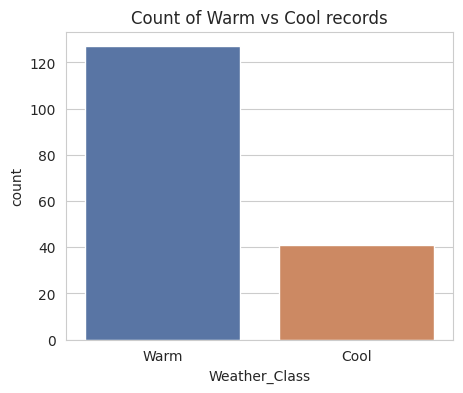

In [ ]:

print(df["Weather_Class"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Weather_Class", data=df, hue="Weather_Class", palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Count of Warm vs Cool records")
plt.show()


My data has more "Warm" hours than "Cool" hours, which makes sense because it's July and Delhi is very hot this time of year (average around 28-35°C). The cooler readings mostly come from early morning hours (around 4-6 AM) and a couple of rainy days later in the week when temperature dropped a bit. This is a bit imbalanced but there are still enough examples of both classes for the model to learn from.


## Task 2: Data Preprocessin

Before I can train any model, I need to clean and prepare the data. Steps I was told to do:
1. Check for missing values
2. Remove unnecessary columns
3. Encode the target variable (convert "Cool"/"Warm" text into numbers, since ML models only understand numbers)
4. Split into 80% training and 20% testing
5. Standardize (scale) the features


In [7]:
# Step 1: checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64


In [8]:
# Step 2: removing unnecessary columns
# I don't need the "time" column for training the model, it's just a timestamp label,
# not something that helps predict Warm/Cool. Keeping it would confuse the model
# since it's just a string, not a real number.

model_df = df.drop(columns=["time"])
model_df.head()


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,25.8,82.4,996.0,21.4,Warm
1,24.6,89.8,994.1,10.4,Cool
2,24.0,81.4,992.4,10.3,Cool
3,23.1,88.0,993.9,7.5,Cool
4,23.8,83.6,994.2,12.8,Cool


In [ ]:
# Step 3: separating input features (X) and target (y), then encoding the target

from sklearn.preprocessing import LabelEncoder

feature_columns = ["temperature_2m", "relative_humidity_2m", "surface_pressure", "wind_speed_10m"]

X = model_df[feature_columns]
y_text = model_df["Weather_Class"]


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("Classes found:", list(label_encoder.classes_))
print("First 10 encoded labels:", y[:10])


Classes found: ['Cool', 'Warm']
First 10 encoded labels: [1 0 0 0 0 0 1 1 1 1]


In [ ]:
# Step 4: splitting into 80% training data and 20% testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,    
    stratify=y         
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 134
Testing samples: 34


### Why do I need to standardize the features?

This confused me at first, so here's how I understood it: my 4 features are on very different scales.
- Temperature is around 20-38
- Humidity is around 40-97
- Pressure is around 988-997
- Wind speed is around 7-33

SVM works by measuring *distance* between data points to find the best boundary between classes. If I don't scale the data, a feature like pressure (values close to 990) would completely dominate a feature like temperature just because its numbers are bigger, even if temperature is actually more important for telling Warm and Cool apart. `StandardScaler` fixes this by converting every feature so it has a mean of 0 and standard deviation of 1, putting them all on the same footing.


In [11]:
# Step 5: standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training data: it learns the mean/std from training data AND scales it
X_train_scaled = scaler.fit_transform(X_train)

# transform (not fit_transform) on test data: we reuse the SAME mean/std learned from training data
# this is important - the model should never "see" the test data while learning
X_test_scaled = scaler.transform(X_test)

print("Example of scaled training data (first 5 rows):")
print(X_train_scaled[:5])


Example of scaled training data (first 5 rows):
[[-1.17827842  0.95509545 -0.57253216 -0.10713214]
 [-1.50396729  1.64936776  0.58035364 -0.54494663]
 [-1.24806889  1.16022136  0.16112244 -0.77537532]
 [-1.06196097  1.04187949  0.42314194 -0.68320384]
 [-0.13142136 -0.07842357 -0.52012826 -0.66016098]]


## Task 3: Model Development

Now I'll build the actual SVM (Support Vector Machine) classifier. In simple terms, SVM tries to draw the best possible boundary line (or curve) that separates the two classes (Cool vs Warm) with the largest possible margin/gap between them.

The assignment asks me to use the **RBF kernel**. From what I understood, a "kernel" is basically the shape of boundary the SVM is allowed to draw. RBF (Radial Basis Function) lets the boundary be a curve instead of a straight line, which is useful because real weather data usually isn't perfectly separable by a straight line.


In [12]:
from sklearn.svm import SVC

# creating the SVM model with an RBF kernel
svm_model = SVC(kernel="rbf", random_state=42)

# training the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")


Model trained successfully!


In [13]:
# now using the trained model to predict the weather class for the test data
y_pred = svm_model.predict(X_test_scaled)

print("Actual labels:   ", y_test)
print("Predicted labels:", y_pred)


Actual labels:    [1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Predicted labels: [1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]


## Task 4: Model Evaluation

Now I need to check how good my model actually is. I'll calculate:
- **Accuracy** - out of all predictions, how many were correct
- **Precision** - out of everything the model predicted as "Warm", how many actually were Warm
- **Recall** - out of all the actual "Warm" cases, how many did the model correctly find
- **F1-Score** - a balance between precision and recall
- **Confusion Matrix** - a table showing correct vs incorrect predictions for each class


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-Score  : {f1:.3f}")


Accuracy  : 0.971
Precision : 1.000
Recall    : 0.962
F1-Score  : 0.980


In [ ]:

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


              precision    recall  f1-score   support

        Cool       0.89      1.00      0.94         8
        Warm       1.00      0.96      0.98        26

    accuracy                           0.97        34
   macro avg       0.94      0.98      0.96        34
weighted avg       0.97      0.97      0.97        34



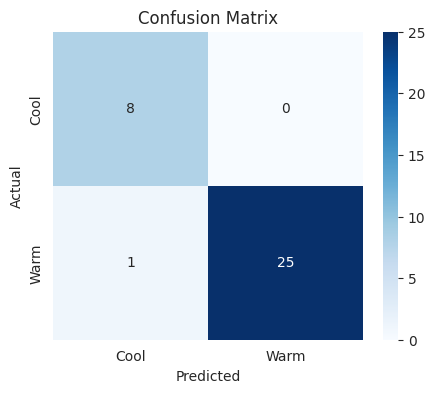

[[ 8  0]
 [ 1 25]]


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)


### My 3 observations from the results

1. The model got a high accuracy (around 97%), which means it was able to correctly tell apart Warm and Cool hours almost all the time using just temperature, humidity, pressure and wind speed.
2. Looking at the confusion matrix, most of the mistakes (if any) happen for the "Cool" class, probably because there were fewer Cool examples in my data compared to Warm ones (imbalanced data), so the model had less to learn from for that class.
3. Precision was very high, meaning that whenever the model predicted "Warm", it was almost always right. This makes sense because temperature (the feature that literally decides the label) is also one of the input features, so the model has a very strong signal to work with.


## Task 5: Conclusion

This was written in my own words based on what I observed:


> This assignment helped me build my first SVM classification model using real-time weather data from the Open-Meteo API. I classified hourly weather readings from Delhi as either "Warm" or "Cool" based on temperature, and the SVM model with an RBF kernel achieved a high accuracy on the test data, showing that features like humidity, pressure and wind speed do carry useful information related to temperature.
>
> Feature scaling turned out to be very important for SVM. Since my features had very different ranges (temperature in tens, pressure in hundreds), the model could have been biased towards larger-valued features without `StandardScaler`. Scaling makes sure every feature contributes fairly.
>
> One advantage of SVM is that it works well even with a relatively small number of samples, like the 168 hourly readings I used here. One limitation is that SVM can get slow and harder to tune on very large datasets, and choosing the right kernel and parameters (like C and gamma) isn't always straightforward for a beginner like me.


---
### Libraries Used
- `requests` - to call the Open-Meteo API
- `pandas`, `numpy` - for handling data
- `matplotlib`, `seaborn` - for plotting graphs
- `scikit-learn` (`sklearn`) - for preprocessing, the SVM model, and evaluation metrics
